# EDA

# 0/ Importing Libraries

In [1]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

pd.set_option("display.max_colwidth", None)   

In [2]:
meta_data = r"../../data/processed/ad_break_level_meta/ad_break_level_PESR_data.parquet"
meta_data_2 = r"../../data/processed/ad_break_level_meta/temporal_ad_break_level_PESR_data.parquet"
bin5s_path = r"../../data/processed/eeg/separated/bin5s_obt.parquet"
segment_path = r"../../data/processed/eeg/separated/segments_obt.parquet"

# - Key Check

In [3]:
# Data Columns Exploration
def get_cols(path):
    return pd.read_parquet(path).columns.tolist()

# Get the lists of names
c1 = get_cols(meta_data)
c2 = get_cols(meta_data_2)
c3 = get_cols(bin5s_path)
c4 = get_cols(segment_path)

columns = {
    'meta_data':   pd.Series(c1, index=c1),
    'meta_data_2': pd.Series(c2, index=c2),
    'bin5s_data':  pd.Series(c3, index=c3),
    'segments':    pd.Series(c4, index=c4),
}

# pd.DataFrame(columns).sort_values(by=['meta_data', 'meta_data_2']).fillna('') \
    # .to_excel(
    # '../../data/final_for_modeling/data_columns.xlsx', index=False)

In [4]:
#keys
K1 = pd.read_parquet(meta_data)['path'].unique().tolist()
K2 = pd.read_parquet(meta_data_2)['path'].unique().tolist()
K3 = pd.read_parquet(bin5s_path)['key'].unique().tolist()
K4 = pd.read_parquet(segment_path)['key'].unique().tolist()


Keys = {
    'meta_data':   pd.Series(K1, index=K1),
    'meta_data_2': pd.Series(K2, index=K2),
    'bin5s_data':  pd.Series(K3, index=K3),
    'segments':    pd.Series(K4, index=K4),
}

pd.DataFrame(Keys).sort_values(by=['meta_data', 'meta_data_2']).fillna('') \
    .to_excel(
    '../../data/final_for_modeling/key_status.xlsx', index=False)

In [5]:
#Segment Keys
SK1 = (pd.read_parquet(meta_data)['path'] + ' - ' + pd.read_parquet(meta_data)['brand']).unique().tolist()
SK2 = (pd.read_parquet(meta_data_2)['path'] + ' - ' + pd.read_parquet(meta_data_2)['brand']).unique().tolist()
SK3 = (pd.read_parquet(bin5s_path)['key'] + ' - ' + pd.read_parquet(bin5s_path)['stimuli_name_clean']).unique().tolist()
SK4 = (pd.read_parquet(segment_path)['key'] + ' - ' + pd.read_parquet(segment_path)['stimuli_name_clean']).unique().tolist()

SKeys = {
    'meta_data':   pd.Series(SK1, index=SK1),
    'meta_data_2': pd.Series(SK2, index=SK2),
    'bin5s_data':  pd.Series(SK3, index=SK3),
    'segments':    pd.Series(SK4, index=SK4),
}

pd.DataFrame(SKeys).sort_values(by=['meta_data', 'meta_data_2']).fillna('') \
    .to_excel(
    '../../data/final_for_modeling/segment_key_status.xlsx', index=False)

# - Metadata (ad_break level data from Survey)

# 1/ Loading Data

In [ ]:
ad_break_df = pd.read_parquet(meta_data_2)
ad_break_df.head()

# 2/ Analysis

## 2.1/ Univariate Analysis

### target

In [7]:
print('proportion of target variable classes:')
print(ad_break_df.unaided_brand_recall.value_counts(normalize=True).round(2))

proportion of target variable classes:
unaided_brand_recall
1    0.67
0    0.33
Name: proportion, dtype: Float64


### 'start_ms', 'end_ms', 'duration'

duration is already cleaned in 1_segments_bins_EEG_cleaning.ipynb

In [8]:
print("Number of ad breaks with negative duration:", len(ad_break_df[ (ad_break_df['end_ms'] < ad_break_df['start_ms'])]))

Number of ad breaks with negative duration: 0


In [ ]:
ad_break_df['start'] = (ad_break_df.start_ms/1000).round()


plt.figure(figsize=(15, 3))
plt.title('Ad Breaks Timeline by Content Watched')
sns.scatterplot(
    data=ad_break_df.sort_values(by='stimuli_type_order'),
    x='start',
    y='stimuli_type_order',
    hue='content_watched',
    legend=False,
    alpha=0.5
)
plt.show()

< RemovedDueToNDA >

###  date

In [10]:
ad_break_df.date.value_counts()

date
2024-05-08    261
2024-05-10    235
2024-05-13    230
2024-05-14    212
2024-05-06    208
2024-05-07    202
2024-05-03    193
2024-05-09    192
2024-04-23    155
2024-05-02    142
2024-04-24    137
2024-04-22    136
2024-04-30    136
2024-04-18    130
2024-04-17    124
2024-04-29    114
2024-04-19     98
2024-05-15     33
Name: count, dtype: int64

analysis of different dates between each sequence of attendance

In [11]:
ad_break_df.groupby(['participant_id_calculated']).agg(
    first = ('date', 'min'),
    last = ('date', 'max'),
    n = ('date', 'count'),
    unique_dates = ('date', 'nunique')
).reset_index()['unique_dates'].describe()

count    283.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: unique_dates, dtype: float64

> All sequences of attendance for each participant happen on the same date. 

### experiment_sequence

In [12]:
print('proportion of experiment sequences:')
ad_break_df.experiment_sequence.value_counts(normalize=True).round(2)

proportion of experiment sequences:


experiment_sequence
2    0.52
1    0.48
Name: proportion, dtype: float64

### category, subcategory, brand

In [13]:
print("number of ad breaks for each brand:")

ad_break_df[['brand', 'category', 'subcategory']].fillna('-').value_counts(normalize=True).round(2).reset_index().sort_values(by=['category', 'subcategory', 'brand'])

number of ad breaks for each brand:


,brand,category,subcategory,proportion
4,< RemovedDueToNDA >,alim,biscotti,0.08
0,< RemovedDueToNDA >,alim,pasta,0.18
3,< RemovedDueToNDA >,alim,sughi,0.08
12,< RemovedDueToNDA >,arred,-,0.05
11,< RemovedDueToNDA >,auto,-,0.05
6,< RemovedDueToNDA >,bev,acqua,0.07
10,< RemovedDueToNDA >,bev,gas,0.06
5,< RemovedDueToNDA >,bev,veg,0.07
8,< RemovedDueToNDA >,cosm,-,0.06
9,< RemovedDueToNDA >,ecomm,-,0.06


### content_watched

In [14]:
print("Statistics of count of content_watched:")
print('first ad break per content watched, then stats calculated as:')
ad_break_df.content_watched.value_counts().describe().round().rename('ad break per content watched')

Statistics of count of content_watched:
first ad break per content watched, then stats calculated as:


count     45.0
mean      65.0
std       21.0
min       23.0
25%       49.0
50%       65.0
75%       81.0
max      114.0
Name: ad break per content watched, dtype: float64

mean: 
- 45 different content, 
- on average 65 ad breaks per content

### ads_break_duration_s

In [15]:
print("proportion of ad break duration (s):")
ad_break_df.groupby('path').ads_break_duration_s.min().value_counts(normalize=True).round(2)   

proportion of ad break duration (s):


ads_break_duration_s
180    0.34
120    0.34
60     0.32
Name: proportion, dtype: float64

In [16]:
print("count of ad breaks per ad break duration (s) and content duration:")
pd.crosstab(
    ad_break_df['ads_break_duration_s'],
    ad_break_df['duration'],
    margins=True
)

count of ad breaks per ad break duration (s) and content duration:


duration,15.0,30.0,All
ads_break_duration_s,,,
60,124,301,425
120,528,503,1031
180,828,654,1482
All,1480,1458,2938


### device

In [17]:
print("count of ad breaks per device:")
ad_break_df.device.value_counts()

count of ad breaks per device:


device
laptop        1041
television     951
smartphone     946
Name: count, dtype: int64

### n_bev_ads, n_alim_ads, seen_ad_before

In [ ]:
ad_break_df

In [19]:
print('unknown status of seen_ad_before:', (ad_break_df.seen_ad_before.isna().sum() / len(ad_break_df)*100).round(2))
print('count of unknown status of seen_ad_before:', ad_break_df.seen_ad_before.isna().sum())

print('-'*80)
print('count of seen_ad_before:')
ad_break_df.seen_ad_before.value_counts()

unknown status of seen_ad_before: 24.78
count of unknown status of seen_ad_before: 728
--------------------------------------------------------------------------------
count of seen_ad_before:


seen_ad_before
1.0    1159
0.0    1051
Name: count, dtype: int64

### Survey Questions

In [20]:
q = ['q_content_pleasantness',
 'q_content_engagement',
 'q_content_interest',
 'q_content_quality',
 'q_content_production_quality',
 'q_ad_quality',
 'q_ad_balance',
 'q_ad_creativity',
 'q_ad_engagement',
 'q_ad_brand_influence']

ad_break_df[q].describe().round(2)

,q_content_pleasantness,q_content_engagement,q_content_interest,q_content_quality,q_content_production_quality,q_ad_quality,q_ad_balance,q_ad_creativity,q_ad_engagement,q_ad_brand_influence
count,2938.0,2938.0,2938.0,2938.0,2938.0,2938.0,2938.0,2938.0,2938.0,2938.0
mean,7.26,7.34,7.29,7.36,7.8,5.58,4.97,5.01,4.87,3.72
std,2.06,2.09,2.23,2.09,1.79,1.09,1.49,1.45,1.47,1.68
min,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,6.0,6.0,6.0,7.0,7.0,5.0,4.0,4.0,4.0,2.0
50%,8.0,8.0,8.0,8.0,8.0,6.0,5.0,5.0,5.0,4.0
75%,8.0,9.0,9.0,9.0,9.0,6.0,6.0,6.0,6.0,5.0
max,10.0,10.0,10.0,10.0,10.0,7.0,7.0,7.0,7.0,7.0


In [21]:
plt.figure(figsize=(5,4))
sns.heatmap(ad_break_df[q].corr(), annot=True, cmap='coolwarm', fmt=".1f", cbar=False)
plt.xticks(fontsize=5)
plt.yticks(fontsize=5)
plt.show()

<< RemovedDueToNDA >>

> Top 5 features (q_content_*) are highly correlated (0.8–0.9) → represent one latent dimension → Content Perception.

> Middle block (q_ad_* except brand influence) is moderately correlated (0.5–0.8) → second dimension → Ad Evaluation.

> q_ad_brand_influence is weakly related or inverse → acts as a separate construct → Brand Impact.

### Age

In [22]:
ad_break_df[['age', 'birth_year']].value_counts().reset_index()

,age,birth_year,count
0,48,1976,126
1,19,2005,103
2,57,1967,93
3,50,1974,89
4,46,1978,89
5,34,1990,89
6,24,2000,84
7,33,1991,83
8,62,1962,82
9,54,1970,78


In [23]:
ad_break_df['age_group'] = pd.cut(
    ad_break_df['age'], 
    bins=[17, 24, 34, 44, 54, 64, 100], 
    labels=['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
)
ad_break_df.age_group.value_counts(normalize=True).round(2)

age_group
45-54    0.22
55-64    0.21
25-34    0.17
18-24    0.14
35-44    0.13
65+      0.13
Name: proportion, dtype: float64

### Gender

In [24]:
print("proportion of gender:")
ad_break_df['gender'].value_counts()

proportion of gender:


gender
female    1470
male      1456
other       12
Name: count, dtype: int64

### participant_id_calculated

In [25]:
print("stats of count of ad breaks for each participant_id_calculated:")
ad_break_df.groupby('participant_id_calculated').size().describe().round(2)

stats of count of ad breaks for each participant_id_calculated:


count    283.00
mean      10.38
std        3.23
min        2.00
25%        8.00
50%       11.00
75%       13.00
max       16.00
dtype: float64

- 283 participant,
- 10.38 ads per participant on average
- min 2 and max 16 ad breaks

### stimuli_type_order

In [26]:
ad_break_df['stimuli_type_order'].value_counts().sort_index()

stimuli_type_order
ad_1    531
ad_2    532
ad_3    451
ad_4    357
ad_5    354
ad_6    289
ad_7    193
ad_8    154
ad_9     77
Name: count, dtype: int64

In [27]:
print("count of ad breaks per session:")
ad_break_df.groupby('path').size().value_counts().sort_index().rename_axis('number_of_ad_breaks_in_session')

count of ad breaks per session:


number_of_ad_breaks_in_session
1     1
2    82
3    90
4     7
5    67
6    96
7    38
8    79
9    74
Name: count, dtype: int64

## 2.2/ Multivariate Analysis

##### Initial Check

Behavior of variables relative to Target >>

In [28]:
target_col = ['unaided_brand_recall']
numerical_cols = ad_break_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove(target_col[0])
categorical_cols = ad_break_df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


Corr of Numerical Variables together

In [29]:
plt.figure(figsize=(10,10))
sns.heatmap(
    ad_break_df[numerical_cols + target_col].drop(columns=['has_ad']).corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".1f",
    cbar=False
)
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.yticks(fontsize=6)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

<< RemovedDueToNDA >>

###### Target with categorical variables: **Chi-Square Test** 

**Interpretation Criteria**

H0 (Null Hypothesis) states there's no relationship or association between categorical variables (they are independent), while H1 (Alternative Hypothesis) claims there is a significant association or difference (they are dependent)

* p-value < 0.05:

		→ Reject the null hypothesis.
		→ The variables are significantly associated (dependent).

* p-value ≥ 0.05:

		→ Fail to reject the null hypothesis.
		→ The variables are not significantly associated (independent).

In [30]:
from scipy.stats import chi2_contingency
def chi_square_for_categoricals(df, target, cat_cols, alpha=0.05):
    results = []

    for col in cat_cols:
        # Build contingency table
        contingency = pd.crosstab(df[col], df[target])

        # Run chi-square
        chi2, p, dof, expected = chi2_contingency(contingency)
        
        if p < alpha:
            interpretation = '✅'
        else:
            interpretation = '❌'
            
        results.append({
            "feature": col,
            "chi2_stat": chi2,
            "p_value": p,
            "interpretation": interpretation,
            "dof": dof,
            "levels_feature": contingency.shape[0],
            "levels_target": contingency.shape[1]
        })

    results_df = pd.DataFrame(results).sort_values(by="p_value")
    return results_df


result = chi_square_for_categoricals(ad_break_df, target=target_col[0], cat_cols=categorical_cols, alpha=0.01)
print(result.round(4))

              feature  chi2_stat  p_value interpretation  dof  levels_feature  \
5               brand   283.1793   0.0000              ✅   12              13   
4         subcategory   162.9887   0.0000              ✅    5               6   
3            category   116.5684   0.0000              ✅    8               9   
1         response_id   888.2331   0.0000              ✅  533             534   
0                path   888.2331   0.0000              ✅  533             534   
8              gender    25.4085   0.0000              ✅    2               3   
9           age_group    32.5243   0.0000              ✅    5               6   
6     content_watched    91.5156   0.0000              ✅   44              45   
2  stimuli_type_order    24.6016   0.0018              ✅    8               9   
7              device     4.3912   0.1113              ❌    2               3   

   levels_target  
5              2  
4              2  
3              2  
1              2  
0            

based on the chi-square test results:
> we can drop device! as there is no significant association with the target variable.

###### Target with Numeric variables: **T-Test** 

interpretation Criteria
H0 (Null Hypothesis) states that there is no significant difference between the means of the two groups, while H1 (Alternative Hypothesis) claims that there is a significant difference between the means of the two groups.

* p-value < 0.05:

        → Reject the null hypothesis.
        → The means of the two groups are significantly different.

* p-value ≥ 0.05: 

        → Fail to reject the null hypothesis.
        → The means of the two groups are not significantly different.

In [31]:
from scipy.stats import ttest_ind
def numeric_vs_binary(df, numeric_cols, target, alpha=0.05):
    results = []

    for col in numeric_cols:
        group0 = df[df[target] == 0][col].dropna()
        group1 = df[df[target] == 1][col].dropna()

        t_stat, p_value = ttest_ind(group0, group1, equal_var=False)

        results.append({
            "feature": col,
            "t_stat": t_stat,
            "p_value": p_value,
            "interpration": '✅' if p_value < alpha else '❌',
            "mean_0": group0.mean().round(2),
            "mean_1": group1.mean().round(2),
            "diff": (group1.mean() - group0.mean()).round(2)
        })

    return pd.DataFrame(results).sort_values(by="p_value")

result_numeric = numeric_vs_binary(ad_break_df, numeric_cols=numerical_cols, target=target_col[0])
print(result_numeric.round(3))

                         feature  t_stat  p_value interpration     mean_0  \
4            experiment_sequence -10.815    0.000            ✅       1.39   
6                      n_bev_ads   4.286    0.000            ✅       1.46   
19               q_ad_engagement  -4.083    0.000            ✅       4.71   
18               q_ad_creativity  -4.050    0.000            ✅       4.85   
1                       start_ms   3.986    0.000            ✅  457646.97   
22                         start   3.986    0.000            ✅     457.65   
2                         end_ms   3.863    0.000            ✅  480535.05   
20          q_ad_brand_influence   3.381    0.001            ✅       3.87   
5           ads_break_duration_s   3.269    0.001            ✅     145.21   
7                     n_alim_ads   2.461    0.014            ✅       2.18   
3                       duration  -1.907    0.057            ❌      22.07   
16                  q_ad_quality  -1.816    0.070            ❌       5.53   

/Applications/anaconda3/envs/thesis/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


----

##### Recall in `experiment_sequence`

In [32]:
print('proportion of ads recall by experiment sequence')
plt.figure(figsize=(3, 3))
sns.heatmap(
    pd.crosstab(
        ad_break_df['experiment_sequence'],
        ad_break_df['unaided_brand_recall'],
        normalize='index'
    ),
    annot=True,
    fmt='.2f',
    cbar=False,
    cmap= 'Blues'
)
plt.title('Proportion of Ads Recall by Experiment Sequence over Index')
plt.show()

print('count of ads recall by experiment sequence')
print(
    pd.crosstab(
        ad_break_df['experiment_sequence'],
        ad_break_df['unaided_brand_recall'],
    ))

proportion of ads recall by experiment sequence


count of ads recall by experiment sequence
unaided_brand_recall    0     1
experiment_sequence            
1                     600   797
2                     378  1163


##### Repetition in each sequence

**Repetition across sequences**

In [33]:
print('average count of \n      ads of brand x \n      experiment sequence \n      for each participant:')
ad_break_df.groupby([ 'participant_id_calculated', 'experiment_sequence', 'brand']).agg(
    count = ('brand', 'count')
).mean().rename('avg_count_of_ads')

average count of 
      ads of brand x 
      experiment sequence 
      for each participant:


count    1.0
Name: avg_count_of_ads, dtype: float64

> No one has seen any repetition in the sequences.

In [34]:
repetition = ad_break_df.groupby(['participant_id_calculated', 'brand']).agg(
    count = ('brand', 'count')
).reset_index()
print("repetition df preview:")
display(repetition.sort_values(by='count', ascending=False).head())

print(f"Number of ad repetition cases: {repetition[repetition['count'] > 1].shape[0]} , or ad segments seen more than once by participants")
print(f"which Percentage to all ad breaks: {repetition[repetition['count'] > 1].shape[0]/len(repetition)*100:.2f}%")

print("Number of participants who have seen any brand more than once:", repetition[repetition['count'] > 1]['participant_id_calculated'].nunique())
print("Total number of participants:", ad_break_df['participant_id_calculated'].nunique())

repetition df preview:


,participant_id_calculated,brand,count
1678,217,< RemovedDueToNDA >,2
1945,256,< RemovedDueToNDA >,2
433,55,< RemovedDueToNDA >,2
1765,232,< RemovedDueToNDA >,2
435,55,< RemovedDueToNDA >,2


Number of ad repetition cases: 619 , or ad segments seen more than once by participants
which Percentage to all ad breaks: 26.69%
Number of participants who have seen any brand more than once: 250
Total number of participants: 283


**Repetition across participants**

Descriptive statistics of repeated ads for each participant:


count    250.00
mean       2.48
std        1.30
min        1.00
25%        1.00
50%        2.00
75%        3.00
max        6.00
dtype: float64

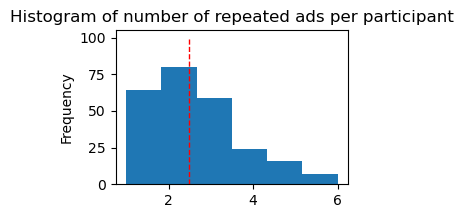

In [35]:
print("Descriptive statistics of repeated ads for each participant:")
display(repetition[repetition['count'] > 1].groupby('participant_id_calculated').size().describe().round(2))


repetition[repetition['count'] > 1].groupby('participant_id_calculated').size().plot(kind='hist', bins=6, figsize=(3, 2))
plt.vlines(repetition[repetition['count'] > 1].groupby('participant_id_calculated').size().describe()['mean'], 0, 100, color='red', linestyle='dashed', linewidth=1)
plt.title('Histogram of number of repeated ads per participant')
plt.show()

250 participants have seen any brand more than once. at least 1 and at most 6 times.
on average, each of these participants have seen 2.46 repetitions.


**Repetition across brand**

In [36]:
print("Percentage of ads repetitions by brand:")
print("of participants who have seen a brand, how many times they have seen it:")
display(
pd.crosstab(
    repetition['brand'],
    repetition['count'], #  how many times one participant saw ad
    normalize='index',
    margins=True
).round(2)*100
)
print('each cell is participants count [share]')

Percentage of ads repetitions by brand:
of participants who have seen a brand, how many times they have seen it:


count,1,2
brand,,
< RemovedDueToNDA >,85.0,15.0
< RemovedDueToNDA >,83.0,17.0
< RemovedDueToNDA >,74.0,26.0
< RemovedDueToNDA >,86.0,14.0
< RemovedDueToNDA >,89.0,11.0
< RemovedDueToNDA >,74.0,26.0
< RemovedDueToNDA >,91.0,9.0
< RemovedDueToNDA >,86.0,14.0
< RemovedDueToNDA >,13.0,87.0


each cell is participants count [share]


In [37]:
#====> I don't have the second viewing info of those 14 percents! I have the percentage of ad shown counts.

##### Recall for `brand`

all 

In [38]:
print('brand memorability (unaided brand recall % by brand):')

brand_memorability = pd.crosstab(
        ad_break_df['brand'],
        ad_break_df['unaided_brand_recall'],
        normalize='index',
        margins=True
    ).round(2)*100

display(brand_memorability)

brand_memorability[1].sort_values().plot(kind='bar', figsize=(10,2), legend=True)
plt.title('Brand Memorability (Unaided Brand Recall % by Brand)')
plt.xticks(fontsize=8)
plt.yticks(range(0, 101, 20))
plt.show()

brand memorability (unaided brand recall % by brand):


unaided_brand_recall,0,1
brand,,
< RemovedDueToNDA >,9.0,91.0
< RemovedDueToNDA >,35.0,65.0
< RemovedDueToNDA >,24.0,76.0
< RemovedDueToNDA >,30.0,70.0
< RemovedDueToNDA >,15.0,85.0
< RemovedDueToNDA >,18.0,82.0
< RemovedDueToNDA >,28.0,72.0
< RemovedDueToNDA >,26.0,74.0
< RemovedDueToNDA >,49.0,51.0


<Figure size 1000x200 with 1 Axes>

Hyphothesis: may be depends on ad expendiniture or Year of establishment of the brand.

In [ ]:
# Data gathered from the previous search
data = {
    'Company': [
        '< RemovedDueToNDA >', '< RemovedDueToNDA >', '< RemovedDueToNDA >', '< RemovedDueToNDA >', '< RemovedDueToNDA >', '< RemovedDueToNDA >', 
        '< RemovedDueToNDA >', '< RemovedDueToNDA >', '< RemovedDueToNDA >', '< RemovedDueToNDA >', '< RemovedDueToNDA >', 
        '< RemovedDueToNDA >', '< RemovedDueToNDA >'
    ],
    'Founding Year': [
        '< RemovedDueToNDA >', '< RemovedDueToNDA >', '< RemovedDueToNDA >', '< RemovedDueToNDA >', '< RemovedDueToNDA >', '< RemovedDueToNDA >', 
        '< RemovedDueToNDA >', '< RemovedDueToNDA >', '< RemovedDueToNDA >', '< RemovedDueToNDA >', '< RemovedDueToNDA >', 
        '< RemovedDueToNDA >', '< RemovedDueToNDA >'
    ]
}
founding_years_df = pd.DataFrame(data)

brand_memorability = brand_memorability.merge(
    founding_years_df,
    left_index=True,
    right_on='Company'
).sort_values('Founding Year')

In [40]:
plt.figure(figsize=(10, 3))

sns.barplot(
    data=brand_memorability.sort_values(by=1),
    x=brand_memorability['Company'],
    y=brand_memorability[1],
    hue=brand_memorability['Founding Year'],
    palette='viridis',
    )

plt.title('Brand Memorability (%)')
plt.ylabel('unaided Brand Recall (%)')
plt.xticks(rotation=90, fontsize=6)
plt.ylim(brand_memorability[1].min()-10, 105)
plt.hlines(ad_break_df.unaided_brand_recall.mean()*100, -1, len(brand_memorability), color='red', linestyle='dashed', linewidth=1, label='Mean Memorability')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)
plt.show()

<Figure size 1000x300 with 1 Axes>

---

##### Recall for brands within sequences

In [41]:
# Prepare data with experiment sequence breakdown
brand_memorability_by_seq = pd.crosstab(
    [ad_break_df['brand'], ad_break_df['experiment_sequence']],
    ad_break_df['unaided_brand_recall'],
    normalize='index'
).round(2) * 100

brand_memorability_by_seq = brand_memorability_by_seq.reset_index()

# Calculate means for horizontal lines
overall_mean = ad_break_df.unaided_brand_recall.mean() * 100
seq1_mean = ad_break_df[ad_break_df['experiment_sequence'] == 1].unaided_brand_recall.mean() * 100
seq2_mean = ad_break_df[ad_break_df['experiment_sequence'] == 2].unaided_brand_recall.mean() * 100

# Create the plot
plt.figure(figsize=(14, 4))

sns.barplot(
    data=brand_memorability_by_seq,
    x='brand',
    y=1,
    hue='experiment_sequence',
    palette=["#002844", "#49022d"],
    alpha=0.7
)

plt.title('Brand Memorability (%) by Experiment Sequence')
plt.ylabel('Unaided Brand Recall (%)')
plt.xlabel('Brand')
plt.xticks(rotation=90, fontsize=7)
plt.ylim(0, 105)

# Add horizontal lines
plt.hlines(overall_mean, -0.5, len(brand_memorability_by_seq['brand'].unique()) - 0.5, 
            color='red', linestyle='-', linewidth=2, label=f'Overall Mean ({overall_mean:.1f}%)')

# plt.hlines(seq1_mean, -0.5, len(brand_memorability_by_seq['brand'].unique()) - 0.5, 
#             color='blue', linestyle='--', linewidth=2, label=f'Seq 1 Mean ({seq1_mean:.1f}%)')

# plt.hlines(seq2_mean, -0.5, len(brand_memorability_by_seq['brand'].unique()) - 0.5, 
#             color='orange', linestyle='--', linewidth=2, label=f'Seq 2 Mean ({seq2_mean:.1f}%)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

# === Separated plots ===

# Separate data by sequence
seq1_data = brand_memorability_by_seq[brand_memorability_by_seq['experiment_sequence'] == 1].copy()
seq2_data = brand_memorability_by_seq[brand_memorability_by_seq['experiment_sequence'] == 2].copy()

# Calculate means for horizontal lines
overall_mean = ad_break_df.unaided_brand_recall.mean() * 100
seq1_mean = ad_break_df[ad_break_df['experiment_sequence'] == 1].unaided_brand_recall.mean() * 100
seq2_mean = ad_break_df[ad_break_df['experiment_sequence'] == 2].unaided_brand_recall.mean() * 100

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Sequence 1 plot
sns.barplot(
    data=seq1_data,
    x='brand',
    y=1,
    color='#002844',
    alpha=0.7,
    ax=ax1
)
ax1.axhline(overall_mean, color='red', linestyle='-', linewidth=1.5, label=f'Overall Mean ({overall_mean:.1f}%)')
ax1.axhline(seq1_mean, color='blue', linestyle='--', linewidth=1.5, label=f'Seq 1 Mean ({seq1_mean:.1f}%)')
ax1.set_title('Sequence 1: Brand Memorability (%)', fontweight='bold')
ax1.set_ylabel('Unaided Brand Recall (%)', fontsize=10)
ax1.set_xlabel('Brand', fontsize=10)
ax1.tick_params(axis='x', rotation=90, labelsize=7)
ax1.set_ylim(0, 105)
ax1.legend(loc='upper right', fontsize=7)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Sequence 2 plot
sns.barplot(
    data=seq2_data,
    x='brand',
    y=1,
    color='#49022d',
    alpha=0.7,
    ax=ax2
)
ax2.axhline(overall_mean, color='red', linestyle='-', linewidth=1.5, label=f'Overall Mean ({overall_mean:.1f}%)')
ax2.axhline(seq2_mean, color='orange', linestyle='--', linewidth=1.5, label=f'Seq 2 Mean ({seq2_mean:.1f}%)')
ax2.set_title('Sequence 2: Brand Memorability (%)', fontweight='bold')
ax2.set_ylabel('')
ax2.set_xlabel('Brand', fontsize=10)
ax2.tick_params(axis='x', rotation=90, labelsize=7)
ax2.set_ylim(0, 105)
ax2.legend(loc='upper right', fontsize=7)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.suptitle('Brand Memorability by Experiment Sequence', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


<Figure size 1400x400 with 1 Axes>

<Figure size 1400x500 with 2 Axes>

In [42]:
# Changes regarding different sessions: 
# Calculate memorability change from sequence 1 to sequence 2
seq1_data = brand_memorability_by_seq[brand_memorability_by_seq['experiment_sequence'] == 1].copy()
seq2_data = brand_memorability_by_seq[brand_memorability_by_seq['experiment_sequence'] == 2].copy()

# Merge to calculate difference
change_data = seq1_data.merge(
    seq2_data,
    on='brand',
    suffixes=('_seq1', '_seq2')
)
change_data['memorability_change'] = change_data['1_seq2'] - change_data['1_seq1']
change_data = change_data.sort_values('memorability_change')

# Create the plot
plt.figure(figsize=(8, 4))

colors = ['#d62728' if x < 0 else '#2ca02c' for x in change_data['memorability_change']]

bars = plt.barh(change_data['brand'], change_data['memorability_change'], color=colors, alpha=0.7)

plt.axvline(0, color='black', linewidth=1, linestyle='-')
plt.xlabel('Change in Memorability (Sequence 2 - Sequence 1) (%)', fontsize=11)
plt.ylabel('Brand', fontsize=11)
plt.title('Brand Memorability Change from Sequence 1 to Sequence 2', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, change_data['memorability_change'])):
    label_x = value + (1.5 if value > 0 else -1.5)
    plt.text(label_x, bar.get_y() + bar.get_height()/2, 
             f'{value:+.1f}%', 
             va='center', 
             ha='left' if value > 0 else 'right',
             fontsize=8)

plt.xlim(change_data['memorability_change'].min()-5, change_data['memorability_change'].max()+5)
plt.tight_layout()
plt.show()


# Display the data table
print("\n=== Detailed Change Data ===")
change_summary = change_data[['brand', '1_seq1', '1_seq2', 'memorability_change']].copy()
change_summary.columns = ['Brand', 'Seq 1 (%)', 'Seq 2 (%)', 'Change (%)']
change_summary = change_summary.sort_values('Change (%)', ascending=False)
change_summary.round(2)

<Figure size 800x400 with 1 Axes>


=== Detailed Change Data ===


,Brand,Seq 1 (%),Seq 2 (%),Change (%)
8,< RemovedDueToNDA >,33.0,69.0,36.0
6,< RemovedDueToNDA >,55.0,87.0,32.0
9,< RemovedDueToNDA >,34.0,61.0,27.0
12,< RemovedDueToNDA >,25.0,48.0,23.0
11,< RemovedDueToNDA >,66.0,83.0,17.0
3,< RemovedDueToNDA >,62.0,76.0,14.0
10,< RemovedDueToNDA >,64.0,78.0,14.0
0,< RemovedDueToNDA >,84.0,96.0,12.0
2,< RemovedDueToNDA >,70.0,82.0,12.0
7,< RemovedDueToNDA >,69.0,79.0,10.0


##### Recall for ad position

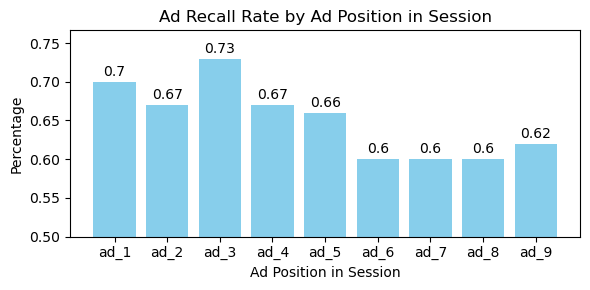

ad recall by ad position in session:


stimuli_type_order
ad_1    0.70
ad_2    0.67
ad_3    0.73
ad_4    0.67
ad_5    0.66
ad_6    0.60
ad_7    0.60
ad_8    0.60
ad_9    0.62
All     0.67
Name: ad recall rate, dtype: float64

In [43]:
pivot = pd.crosstab(
    ad_break_df['stimuli_type_order'],
    ad_break_df['unaided_brand_recall'],
    normalize='index'
).round(2)

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(pivot.index, pivot[1], color='skyblue')
ax.bar_label(bars, padding=2)
plt.ylim(.5)
ax.set_xlabel("Ad Position in Session")
ax.set_ylabel("Percentage")
ax.set_title("Ad Recall Rate by Ad Position in Session")
plt.tight_layout()
plt.show()

print('ad recall by ad position in session:')
pd.crosstab(
    ad_break_df['stimuli_type_order'],
    ad_break_df['unaided_brand_recall'],
    normalize='index',
    margins=True,
).round(2)[1].rename('ad recall rate')

break down by ad break duration:


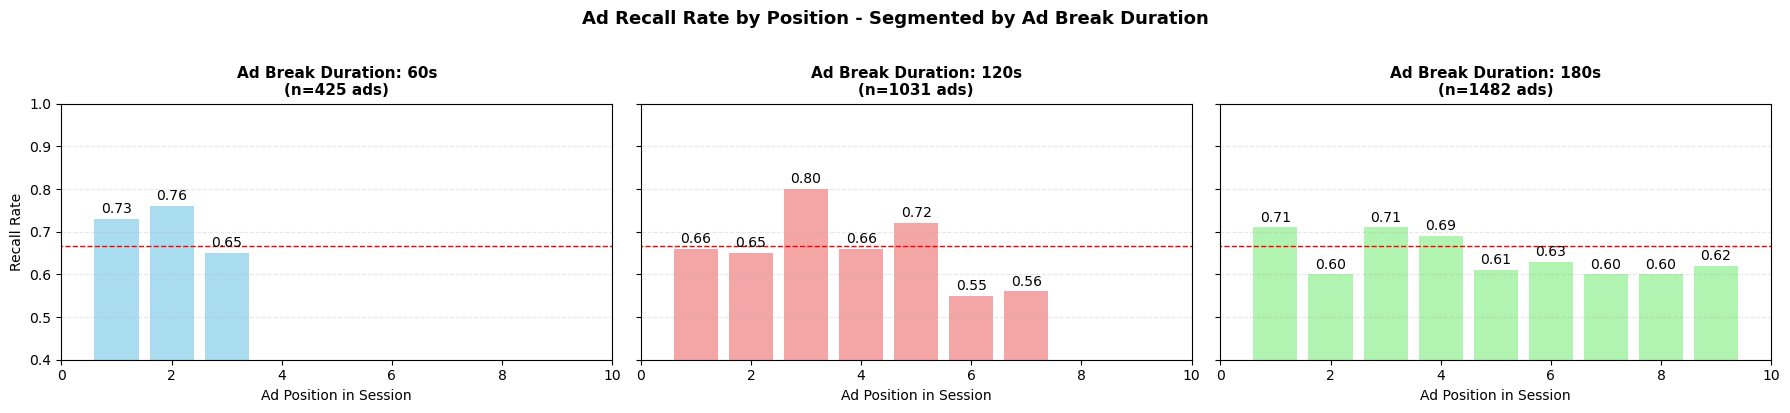


=== Summary Statistics by Ad Break Duration ===

Duration: 60s


ad_position_in_session
1      0.73
2      0.76
3      0.65
All    0.72
Name: ad recall rate, dtype: float64



Duration: 120s


ad_position_in_session
1      0.66
2      0.65
3      0.80
4      0.66
5      0.72
6      0.55
7      0.56
All    0.68
Name: ad recall rate, dtype: float64



Duration: 180s


ad_position_in_session
1      0.71
2      0.60
3      0.71
4      0.69
5      0.61
6      0.63
7      0.60
8      0.60
9      0.62
All    0.64
Name: ad recall rate, dtype: float64

In [44]:
print("break down by ad break duration:")
# Add ad position in session as integer
ad_break_df['ad_position_in_session'] = ad_break_df['stimuli_type_order'].str[-1].astype(int)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

# Get unique ad break durations and sort them
durations = sorted(ad_break_df['ads_break_duration_s'].unique())

# Define colors for each duration
colors = ['skyblue', 'lightcoral', 'lightgreen']

for idx, (duration, ax, color) in enumerate(zip(durations, axes, colors)):
    # Filter data by duration
    df_filtered = ad_break_df[ad_break_df['ads_break_duration_s'] == duration]
    
    # Create crosstab
    pivot = pd.crosstab(
        df_filtered['ad_position_in_session'],
        df_filtered['unaided_brand_recall'],
        normalize='index'
    ).round(2)
    
    # Create bar plot
    bars = ax.bar(pivot.index, pivot[1], color=color, alpha=0.7)
    ax.bar_label(bars, padding=2, fmt='%.2f')
    
    # Set labels and title
    ax.set_xlabel("Ad Position in Session", fontsize=10)
    if idx == 0:
        ax.set_ylabel("Recall Rate", fontsize=10)
    ax.set_title(f"Ad Break Duration: {int(duration)}s\n(n={len(df_filtered)} ads)", 
                fontsize=11, fontweight='bold')
    ax.set_ylim(0.4, 1.0)
    ax.set_xlim(0 , ad_break_df['ad_position_in_session'].max() + 1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.hlines( ad_break_df.unaided_brand_recall.mean(), -1, ad_break_df['ad_position_in_session'].max() + 1, 
            color='red', linestyle='dashed', linewidth=1, label='Overall Mean Recall Rate')

plt.suptitle("Ad Recall Rate by Position - Segmented by Ad Break Duration", 
            fontsize=13, fontweight='bold', y=1.02)


plt.tight_layout()
plt.show()

# Display summary statistics for each duration
print("\n=== Summary Statistics by Ad Break Duration ===\n")
for duration in durations:
    df_filtered = ad_break_df[ad_break_df['ads_break_duration_s'] == duration]
    crosstab = pd.crosstab(
        df_filtered['ad_position_in_session'],
        df_filtered['unaided_brand_recall'],
        normalize='index',
        margins=True,
    ).round(2)[1].rename('ad recall rate')
    
    print(f"Duration: {int(duration)}s")
    display(crosstab)
    print("\n" + "="*50 + "\n")

##### Recall for total ad count in a session

Statistics of mean recall by total ads in session:


,count,mean,std,50%
total_ads_in_session,,,,
2,83.0,0.8,0.32,1.0
3,90.0,0.67,0.32,0.67
4,5.0,0.55,0.41,0.75
5,67.0,0.75,0.21,0.8
6,96.0,0.67,0.26,0.67
7,38.0,0.62,0.26,0.57
8,78.0,0.66,0.26,0.75
9,77.0,0.62,0.22,0.67


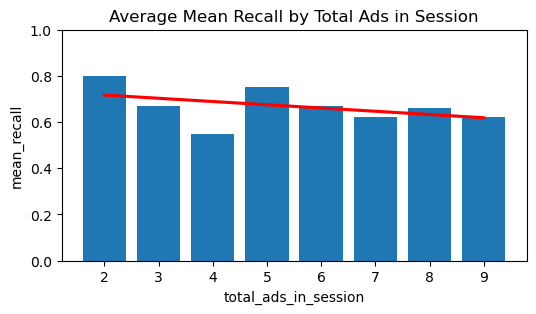

In [45]:
temp = ad_break_df.groupby('path').agg(
    total_ads_in_session = ('ad_position_in_session', 'max'),
    mean_recall = ('unaided_brand_recall', 'mean')   
)
print("Statistics of mean recall by total ads in session:")
display(temp.groupby('total_ads_in_session')['mean_recall'].describe().round(2)[['count', 'mean', 'std', '50%']])

plt.figure(figsize=(6, 3))
sns.boxplot(data=temp, x='total_ads_in_session', y='mean_recall', fill=False)
for mean in temp.groupby('total_ads_in_session')['mean_recall'].mean().items():
    plt.scatter(mean[0]-2, mean[1], color='red', marker='.', s=50)
plt.title("Boxplot of Mean Recall by Total Ads in Session")
plt.show()


temp2 = temp.groupby('total_ads_in_session').mean().round(2)
plt.figure(figsize=(6, 3))
plt.bar(temp2.index, temp2.mean_recall)
sns.regplot(x=temp2.index, y=temp2.mean_recall, scatter=False, ax=plt.gca(), color='red', line_kws={'label':"Trendline"}, ci=False)
plt.ylim(0, 1)
plt.title("Average Mean Recall by Total Ads in Session")
plt.show()

##### Recall vs Time since program start 

In [46]:
ad_break_df['start_m'] = (ad_break_df.start_ms/1000).round()/60  # convert to minutes

plt.figure(figsize=(12, 4))
sns.scatterplot(
    data=ad_break_df,
    x='content_watched',
    y='start_m',
    hue='ad_position_in_session',
    palette='viridis',
    alpha=0.2
)
plt.title('Ad Position in Session vs. Time since Program Start')
plt.xticks(fontsize=6, rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False, axis='x')
plt.show()


In [47]:
plt.figure(figsize=(6, 3))
sns.scatterplot(
    data=ad_break_df,
    x='ad_position_in_session',
    y='start_ms',
    hue='unaided_brand_recall',
    legend=True,
    palette='viridis',
)
plt.title('Ad Position in Session vs. Start Time (ms)')
plt.show()

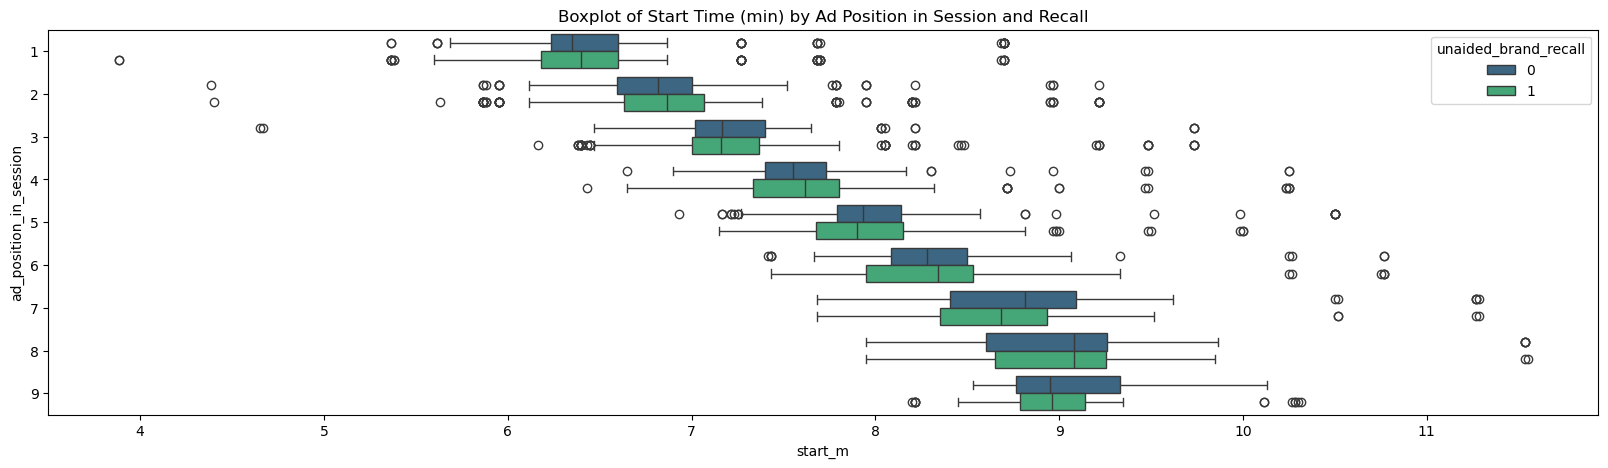

In [48]:
plt.figure(figsize=(20, 5))
sns.boxplot(
    data=ad_break_df,
    y='ad_position_in_session',
    x='start_m',
    hue='unaided_brand_recall',
    legend=True,
    palette='viridis',
    orient ='h',
)

plt.title('Boxplot of Start Time (min) by Ad Position in Session and Recall')
plt.show()

In [49]:
ad_break_df[ad_break_df['ad_position_in_session'] == 1].groupby('content_watched').agg(
    mean_start_ms = ('start_ms', 'mean'),
    mean_recall = ('unaided_brand_recall', 'mean')
).reset_index().sort_values('mean_start_ms').round(2).plot(
    x='content_watched',
    y='mean_recall',
    kind='bar',
    figsize=(20,3),
)
plt.title('Mean Recall by Content Watched')
plt.legend().remove()
plt.xlabel('Content Watched sorted by Mean Start Time of First Ad in Session')
plt.show()

In [50]:
positions = sorted(ad_break_df['ad_position_in_session'].unique())
n_positions = len(positions)
n_cols = 3
n_rows = (n_positions + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), sharey=True)
axes = axes.flatten() if n_positions > 1 else [axes]

for idx, pos in enumerate(positions):
    ax = axes[idx]
    
    # Filter data for this position
    pos_data = ad_break_df[ad_break_df['ad_position_in_session'] == pos].groupby('content_watched').agg(
        mean_start_ms=('start_ms', 'mean'),
        mean_recall=('unaided_brand_recall', 'mean'),
        count=('unaided_brand_recall', 'count')
    ).reset_index().sort_values('mean_start_ms')
    
    # Create bar chart
    ax.bar(range(len(pos_data)), pos_data['mean_recall'], alpha=0.7, color=f'C{idx}')
    ax.set_xticks(range(len(pos_data)))
    ax.set_xticklabels(pos_data['content_watched'], rotation=90, fontsize=6)
    ax.set_ylabel('Mean Recall Rate' if idx % n_cols == 0 else '', fontsize=9)
    ax.set_title(f'Ad Position {int(pos)}\n(n={pos_data["count"].sum()} ads)', 
                fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, 1.05)
    
    # Add mean line
    overall_mean = pos_data['mean_recall'].mean()
    ax.axhline(overall_mean, color='red', linestyle='--', linewidth=1, 
              label=f'Mean: {overall_mean:.2f}')
    ax.legend(fontsize=7)

# Hide extra subplots if any
for idx in range(n_positions, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Brand Recall Rate by Content Watched - Separated by Ad Position in Session', 
            fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

##### Recall vs Program Watched

In [51]:
data = {
    "content_watched": [
        "sky tg24 wow", "le iene inside", "grande fratello", "quarta repubblica",
        "the equalizer", "i fantastici 5 (1)", "vivarai2", "in altre parole",
        "tg metana dataroom", "freedom", "in viaggio con barbero", "ulisse",
        "lolita lobosco", "shindler", "natura meraviglia senza tempo (1)",
        "fuorilegge", "il cavallo e la torre", "4 ristoranti", "amici", "doc",
        "splendida cornice", "mare fuori", "le iene", "masterchef", "terra amara",
        "master and commander", "kilimangiaro", "x-factor", "stasera tutto e possibile",
        "stanotte a parigi", "succession", "c'e posta per te (1)", "segreti foreste incantate",
        "propaganda live", "sky calcio club", "belve", "sky tg24 numeri",
        "tut il destino di un faraone", "domina", "petrolio", "c'e posta per te (2)",
        "ncis", "dritto e rovescio", "una giornata particolare", "otto e mezzo"
    ],
    "program_category": [
        "News", "Investigative", "Reality", "Talk", "Fiction", "Fiction", "Entertainment", "Talk",
        "News", "Documentary", "Documentary", "Documentary", "Fiction", "Fiction", "Documentary",
        "Fiction", "Talk", "Reality", "Reality", "Fiction", "Talk", "Fiction", "Investigative",
        "Reality", "Fiction", "Fiction", "Documentary", "Reality", "Entertainment", "Documentary",
        "Fiction", "Talk", "Documentary", "Talk", "Sports", "Talk", "News", "Documentary",
        "Fiction", "Investigative", "Talk", "Fiction", "Talk", "Talk", "Talk"
    ]
}

cat_program = pd.DataFrame(data)
cat_program.value_counts('program_category')


temp3 = pd.crosstab(
    ad_break_df['content_watched'],
    ad_break_df['unaided_brand_recall'],
    normalize = 'index'
).round(2).merge(cat_program, left_index=True, right_on='content_watched')

temp3

,0,1,content_watched,program_category
17,0.46,0.54,4 ristoranti,Reality
18,0.24,0.76,amici,Reality
35,0.30,0.70,belve,Talk
31,0.30,0.70,c'e posta per te (1),Talk
40,0.30,0.70,c'e posta per te (2),Talk
19,0.48,0.52,doc,Fiction
38,0.33,0.67,domina,Fiction
42,0.32,0.68,dritto e rovescio,Talk
9,0.28,0.72,freedom,Documentary
15,0.29,0.71,fuorilegge,Fiction


In [52]:
# Calculate mean for each category
category_recall = temp3.groupby('program_category')[1].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 3))
# Create barplot
ax = sns.barplot(
    x=category_recall.index,
    y=category_recall.values,
    alpha=0.8
)

# Add value labels on bars
for i, v in enumerate(category_recall.values):
    ax.text(i, v + 0.1, f'{v:.1%}', ha='center', va='bottom') #fontsize=10, fontweight='bold')

# Add overall mean line
overall_mean = temp3[1].mean()
plt.axhline(overall_mean, color='red', linestyle='--', linewidth=2, 
            label=f'Overall Mean: {overall_mean:.1%}', alpha=0.7)

# Formatting
plt.title('Brand Recall Rate by Program Category')
plt.xlabel('Program Category')
plt.ylabel('Unaided Brand Recall Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower left')
plt.show()

In [53]:
result1 = chi_square_for_categoricals(
    ad_break_df.merge(cat_program, left_on='content_watched', right_on='content_watched'), 
    target_col[0], 
    ['program_category'], 
    alpha=0.05)

result1.round(4).T

,0
feature,program_category
chi2_stat,10.506
p_value,0.1617
interpretation,❌
dof,7
levels_feature,8
levels_target,2


In [54]:
data = [
    ["sky tg24 wow", "News", "News & Current Affairs"],
    ["le iene inside", "Investigative", "Factual"],
    ["grande fratello", "Reality", "Entertainment"],
    ["quarta repubblica", "Talk", "News & Current Affairs"],
    ["the equalizer", "Fiction", "Drama"],
    ["i fantastici 5 (1)", "Fiction", "Drama"],
    ["vivarai2", "Entertainment", "Entertainment"],
    ["in altre parole", "Talk", "News & Current Affairs"],
    ["tg metana dataroom", "News", "News & Current Affairs"],
    ["freedom", "Documentary", "Factual"],
    ["in viaggio con barbero", "Documentary", "Factual"],
    ["ulisse", "Documentary", "Factual"],
    ["lolita lobosco", "Fiction", "Drama"],
    ["shindler", "Fiction", "Drama"],
    ["natura meraviglia senza tempo (1)", "Documentary", "Factual"],
    ["fuorilegge", "Fiction", "Drama"],
    ["il cavallo e la torre", "Talk", "News & Current Affairs"],
    ["4 ristoranti", "Reality", "Entertainment"],
    ["amici", "Reality", "Entertainment"],
    ["doc", "Fiction", "Drama"],
    ["splendida cornice", "Talk", "Entertainment"],
    ["mare fuori", "Fiction", "Drama"],
    ["le iene", "Investigative", "Factual"],
    ["masterchef", "Reality", "Entertainment"],
    ["terra amara", "Fiction", "Drama"],
    ["master and commander", "Fiction", "Drama"],
    ["kilimangiaro", "Documentary", "Factual"],
    ["x-factor", "Reality", "Entertainment"],
    ["stasera tutto e possibile", "Entertainment", "Entertainment"],
    ["stanotte a parigi", "Documentary", "Factual"],
    ["succession", "Fiction", "Drama"],
    ["c'e posta per te (1)", "Talk", "Entertainment"],
    ["segreti foreste incantate", "Documentary", "Factual"],
    ["propaganda live", "Talk", "News & Current Affairs"],
    ["sky calcio club", "Sports", "Sports"],
    ["belve", "Talk", "Entertainment"],
    ["sky tg24 numeri", "News", "News & Current Affairs"],
    ["tut il destino di un faraone", "Documentary", "Factual"],
    ["domina", "Fiction", "Drama"],
    ["petrolio", "Investigative", "Factual"],
    ["c'e posta per te (2)", "Talk", "Entertainment"],
    ["ncis", "Fiction", "Drama"],
    ["dritto e rovescio", "Talk", "News & Current Affairs"],
    ["una giornata particolare", "Talk", "News & Current Affairs"],
    ["otto e mezzo", "Talk", "News & Current Affairs"]
]

cat_program = pd.DataFrame(data, columns=["content_watched", "category", "genre"])
cat_program.groupby(['genre', 'category']).size()

genre                   category     
Drama                   Fiction          12
Entertainment           Entertainment     2
                        Reality           5
                        Talk              4
Factual                 Documentary       8
                        Investigative     3
News & Current Affairs  News              3
                        Talk              7
Sports                  Sports            1
dtype: int64

In [ ]:
# Merge datasets
temp4 = ad_break_df.merge(
    cat_program,
    on='content_watched',
    how='left'
)

# Combine genre and category for richer labeling
temp4['genre-category'] = temp4['genre'] + ' - ' + temp4['category_y']

# Sort by genre-category
temp4.sort_values('genre-category', inplace=True)

# Compute mean recall per genre-category
genre_means = temp4.groupby('genre-category')['unaided_brand_recall'].mean().reset_index()

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=genre_means,
    x='genre-category',
    y='unaided_brand_recall',
    alpha=0.8,
    color='skyblue'
)

# Add horizontal line for overall mean
mean_recall = temp4['unaided_brand_recall'].mean()
ax.axhline(mean_recall, color='red', linestyle='--', linewidth=1.5,
           label=f'Overall Mean: {mean_recall:.2f}')

# Add count labels and mean values on bars
for i, (genre, mean_val) in enumerate(zip(genre_means['genre-category'], genre_means['unaided_brand_recall'])):
    count = temp4[temp4['genre-category'] == genre].shape[0]
    bar = ax.patches[i]

    # Count label below
    ax.text(bar.get_x() + bar.get_width()/2, -0.03,
            f'n={count}', ha='center', va='top', fontsize=9, color='black')

    # Mean value above bar
    ax.text(bar.get_x() + bar.get_width()/2, mean_val + 0.02,
            f'{mean_val:.2f}', ha='center', va='bottom', fontsize=9, color='black')

# Aesthetics
plt.xlabel('Genre - Category', fontsize=11)
plt.ylabel('Mean Unaided Brand Recall', fontsize=11)
plt.title('Brand Recall by Program Genre-Category', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(-0.15, 1.1)
plt.legend(fontsize=9)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [56]:
result2 = chi_square_for_categoricals(
    temp4, 
    target_col[0], 
    ['genre', 'category_y','genre-category'], 
    alpha=0.05)

result2.round(4).T

,1,2,0
feature,category_y,genre-category,genre
chi2_stat,10.506,10.7923,5.6256
p_value,0.1617,0.2137,0.2289
interpretation,❌,❌,❌
dof,7,8,4
levels_feature,8,9,5
levels_target,2,2,2


In [57]:
# Create pivot table
pivot_data = (
    temp4.groupby(['brand', 'genre-category'])['unaided_brand_recall']
    .mean()
    .unstack()
    .astype('float64')
)

# ✅ 1. Sort columns (genres) by overall mean recall
pivot_data = pivot_data[pivot_data.mean(axis=0).sort_values(ascending=False).index]

# ✅ 2. Sort rows (brands) by their mean recall after column sorting
pivot_data = pivot_data.loc[pivot_data.mean(axis=1).sort_values(ascending=False).index]

# Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    cbar_kws={'label': 'Mean Unaided Brand Recall'}
)
plt.title('Brand Recall Mean by Genre-Category (Sorted by Genre → Brand)')
plt.tight_layout()
plt.show()

# Display the sorted pivot
pivot_data.round(2)

<Figure size 800x800 with 2 Axes>

genre-category,Factual - Documentary,Entertainment - Entertainment,Entertainment - Talk,Sports - Sports,News & Current Affairs - Talk,Factual - Investigative,Drama - Fiction,News & Current Affairs - News,Entertainment - Reality
brand,,,,,,,,,
< RemovedDueToNDA >,0.97,0.80,0.90,1.00,0.93,0.91,0.87,NaN,0.91
< RemovedDueToNDA >,0.87,0.86,0.92,1.00,0.86,1.00,0.79,0.75,0.84
< RemovedDueToNDA >,0.95,0.83,0.67,0.60,0.81,0.80,0.80,0.80,0.82
< RemovedDueToNDA >,0.77,0.85,0.88,1.00,0.93,0.27,0.69,0.73,0.85
< RemovedDueToNDA >,0.82,0.83,1.00,1.00,0.75,0.67,0.70,0.50,0.57
< RemovedDueToNDA >,0.78,0.75,0.88,1.00,0.73,0.67,0.69,0.71,0.62
< RemovedDueToNDA >,0.66,0.70,0.75,NaN,0.67,0.62,0.85,0.75,0.56
< RemovedDueToNDA >,0.90,0.75,0.78,0.00,0.83,0.81,0.71,0.80,0.65
< RemovedDueToNDA >,0.83,0.76,0.43,NaN,0.68,0.89,0.63,0.69,0.40


# - EEG Features

**--- Helper Functions ---**
> `export_columns_list` function to create list of columns to export based on transformation type and indices and etc.


In [58]:
metrics_path = "../../data/processed/eeg/metrics.pkl"
with open(metrics_path, 'rb') as metrics_file:
    metrics = pickle.load(metrics_file)
    
def export_columns_list(transformation: list = ['raw'], indices: list = None, bands: list = None, clusters: list = None, channels: list = None, metric: dict = metrics) -> list:
    
    """
    Helper function to create list of columns to export
    # metrics[transformation][index][band][sub_band][cluster][channel]['vars']

    Args:
        metric (dict): metric dictionary
        transformation (str): transformation type: ["raw", "z-all", "z-program", "z-all-log", "z-program-log"]
        indices (list): list of indices: ["mean-psd", "gfp", "ei", "ai", "fa"]
        bands (list): list of bands: ["delta", "theta", "alpha", "beta", "gamma", "ei-1", "ei-2", "ei-3", "ai-1"]
        clusters (list): list of clusters: ["central", "lateral", "all"]
        channels (list): list of channels: ["electrode", "montage"]
        
    Returns:
        list: list of columns to export,
                list of categorized columns
                (transformation, index, band)
    """
    # possible values
    all_transformations = ["raw", "z-all", "z-program", "z-all-log", "z-program-log"]
    all_indices         = ["mean-psd", "gfp", "ei", "ai", "fa"]
    all_bands           = ["delta", "theta", "alpha", "beta", "gamma", "ei-1", "ei-2", "ei-3", "ai-1"]
    sub_by_band = {
    "delta": ["delta_"],
    "theta": ["theta_", "theta-lower_"],
    "alpha": ["alpha_", "alpha-lower-1_", "alpha-lower-2_", "alpha-upper_"],
    "beta":  ["beta_"],
    "gamma": ["gamma_"],
    "ei-1":  ["ei-1a", "ei-1b", "ei-1c", "ei-1d"],
    "ei-2":  ["ei-2a", "ei-2b", "ei-2c", "ei-2d"],
    "ei-3":  ["ei-3a", "ei-3b", "ei-3c", "ei-3d"],
    "ai-1":  ["ai-1a", "ai-1b"],
    }
    all_clusters        = ["central", "lateral", "all"]
    all_channels        = ["electrode", "montage"]

    # set default values
    indices = indices if indices is not None else all_indices
    bands = bands if bands is not None else all_bands
    clusters = clusters if clusters is not None else all_clusters
    channels = channels if channels is not None else all_channels

    # Validate inputs
    if not set(transformation).issubset(all_transformations):
        raise ValueError(f"transformation {transformation} not in {all_transformations}")
    if not set(indices).issubset(all_indices):
        raise ValueError(f"Invalid indices: {set(indices) - set(all_indices)}")
    if not set(bands).issubset(all_bands):
        raise ValueError(f"Invalid bands: {set(bands) - set(all_bands)}")
    if not set(clusters).issubset(all_clusters):
        raise ValueError(f"Invalid clusters: {set(clusters) - set(all_clusters)}")
    if not set(channels).issubset(all_channels):
        raise ValueError(f"Invalid channels: {set(channels) - set(all_channels)}")

    # main logic
    # --- collect leaf variables into 'total_var' ---
    total_var = []
    categorized_list = []
    
    for tfm in transformation:
        m_t = metrics.get(tfm, {})
        for idx in indices:
            m_i = m_t.get(idx, {})
            for band in bands:
                m_b = m_i.get(band, {})
                subs_here = sub_by_band.get(band, list(m_b.keys()))
                temp_cat_list = []
                for sub in subs_here:
                    m_s = m_b.get(sub, {})
                    for cluster in clusters:
                        m_c = m_s.get(cluster, {})
                        for ch in channels:
                            leaf = m_c.get(ch, {})
                            # extract strings from possible leaf structures (dict/list/str)
                            cands = []
                            if isinstance(leaf, dict):
                                if "vars" in leaf and isinstance(leaf["vars"], (list, tuple, set)):
                                    cands = [v for v in leaf["vars"] if isinstance(v, str)]
                                else:
                                    tmp = []
                                    for v in leaf.values():
                                        if isinstance(v, str):
                                            tmp.append(v)
                                        elif isinstance(v, (list, tuple, set)):
                                            tmp += [w for w in v if isinstance(w, str)]
                                    cands = tmp
                            elif isinstance(leaf, (list, tuple, set)):
                                cands = [v for v in leaf if isinstance(v, str)]
                            elif isinstance(leaf, str):
                                cands = [leaf]
                                
                            for v in cands:
                                if v not in total_var:
                                    total_var.append(v)
                                    temp_cat_list.append(v)
                if len(temp_cat_list) != 0:
                    categorized_list.append(temp_cat_list)               
    return total_var, categorized_list

In [59]:
# ttest without sorting by p-value
def numeric_vs_binary(df, numeric_cols, target, alpha=0.05):
    results = []

    for col in numeric_cols:
        group0 = df[df[target] == 0][col].dropna()
        group1 = df[df[target] == 1][col].dropna()

        t_stat, p_value = ttest_ind(group0, group1, equal_var=False)

        results.append({
            "feature": col,
            "t_stat": t_stat,
            "p_value": p_value,
            "interpration": '✅' if p_value < alpha else '❌',
            "mean_0": group0.mean().round(2),
            "mean_1": group1.mean().round(2),
            "diff": (group1.mean() - group0.mean()).round(2)
        })

    return pd.DataFrame(results)#.sort_values(by="p_value")


# 1/ Load Data

In [ ]:
segment = pd.read_parquet(segment_path)
segment.head()

In [ ]:
print(ad_break_df.shape, segment.shape)

df = ad_break_df[['path', 'brand', 'unaided_brand_recall']].merge(segment[segment['stimuli_type'] == 'ad'], left_on=['path', 'brand'], right_on=['key', 'stimuli_name_clean'], how='left')
print(df.shape)
display(df.head())

# (2938, 37) (4070, 2117)
# (2938, 2120)


# 2/ Analysis

### Mean Psd

#### Electrode-level Analysis

In [62]:
SELECTED_TRANSFORMATIONS = ['z-all-log']
SELECTED_CHANNELS = None # ['electrode']
SELECTED_INDEXES = ['mean-psd'] # ['mean-psd', 'gfp', 'ei', 'ai', 'fa']
SELECTED_CLUSTERS = None #['all'] # # ['central', 'lateral', 'all']
SELECTED_CHANNELS = ['electrode']

l, cl = export_columns_list(transformation=SELECTED_TRANSFORMATIONS, 
                            channels=SELECTED_CHANNELS,
                            indices=SELECTED_INDEXES,
                            clusters=SELECTED_CLUSTERS
                            )

print(len(l), len(cl))
print('-'*90)

for i in range(len(cl)):
    group_name = cl[i][0].split('_')[1] + '/' + cl[i][0].split('_')[2]   # extract group name from first variable
    print(f"{group_name}: {cl[i][:3]} ... ({len(cl[i])} variables)")

print('-'*90)
def psd_analysis(df, feature_cols):
    results = numeric_vs_binary(df, feature_cols, 'unaided_brand_recall', alpha=0.05).round(6)
    results['group_name'] = results['feature'].apply(lambda x: x.split('_')[0] + '/' + x.split('_')[1] + '/' + x.split('_')[2])

    print("T-test results summary by group:")
    display(
        pd.crosstab(
            results['group_name'],
            results['interpration'],
            margins=True,
        ).round(2)
    )
    return 


psd_analysis(df, l)
    

63 5
------------------------------------------------------------------------------------------
mean-psd/Delta: ['z-a-log_mean-psd_Delta_Fp1_v^2/Hz', 'z-a-log_mean-psd_Delta_Fpz_v^2/Hz', 'z-a-log_mean-psd_Delta_Fp2_v^2/Hz'] ... (7 variables)
mean-psd/Theta: ['z-a-log_mean-psd_Theta_Fp1_v^2/Hz', 'z-a-log_mean-psd_Theta_Fpz_v^2/Hz', 'z-a-log_mean-psd_Theta_Fp2_v^2/Hz'] ... (14 variables)
mean-psd/Alpha: ['z-a-log_mean-psd_Alpha_Fp1_v^2/Hz', 'z-a-log_mean-psd_Alpha_Fpz_v^2/Hz', 'z-a-log_mean-psd_Alpha_Fp2_v^2/Hz'] ... (28 variables)
mean-psd/Beta: ['z-a-log_mean-psd_Beta_Fp1_v^2/Hz', 'z-a-log_mean-psd_Beta_Fpz_v^2/Hz', 'z-a-log_mean-psd_Beta_Fp2_v^2/Hz'] ... (7 variables)
mean-psd/Gamma: ['z-a-log_mean-psd_Gamma_Fp1_v^2/Hz', 'z-a-log_mean-psd_Gamma_Fpz_v^2/Hz', 'z-a-log_mean-psd_Gamma_Fp2_v^2/Hz'] ... (7 variables)
------------------------------------------------------------------------------------------
T-test results summary by group:


interpration,✅,❌,All
group_name,,,
z-a-log/mean-psd/Alpha,0,7,7
z-a-log/mean-psd/Alpha-lower-1,1,6,7
z-a-log/mean-psd/Alpha-lower-2,0,7,7
z-a-log/mean-psd/Alpha-upper,0,7,7
z-a-log/mean-psd/Beta,1,6,7
z-a-log/mean-psd/Delta,2,5,7
z-a-log/mean-psd/Gamma,2,5,7
z-a-log/mean-psd/Theta,0,7,7
z-a-log/mean-psd/Theta-lower,2,5,7


In [ ]:
plt.figure(figsize=(20, 16))
sns.heatmap(
    df[l].corr(),
    cmap='RdYlBu_r',
    center=0,
    annot=False,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Heatmap of Selected EEG Features')
plt.xticks(fontsize=4)
plt.yticks(fontsize=4)
plt.show()

#### Montage-level Analysis

In [64]:
SELECTED_TRANSFORMATIONS = ['z-all-log']
SELECTED_CHANNELS = None # ['electrode']
SELECTED_INDEXES = ['mean-psd'] # ['mean-psd', 'gfp', 'ei', 'ai', 'fa']
SELECTED_CLUSTERS = None #['all'] # # ['central', 'lateral', 'all']
SELECTED_CHANNELS = ['montage']

l, cl = export_columns_list(transformation=SELECTED_TRANSFORMATIONS, 
                            channels=SELECTED_CHANNELS,
                            indices=SELECTED_INDEXES,
                            clusters=SELECTED_CLUSTERS
                            )

print(len(l), len(cl))
print('-'*90)

for i in range(len(cl)):
    group_name = cl[i][0].split('_')[1] + '/' + cl[i][0].split('_')[2]   # extract group name from first variable
    print(f"{group_name}: {cl[i][:3]} ... ({len(cl[i])} variables)")

print('-'*90)
def psd_analysis(df, feature_cols):
    results = numeric_vs_binary(df, feature_cols, 'unaided_brand_recall', alpha=0.05).round(6)
    results['group_name'] = results['feature'].apply(lambda x: x.split('_')[0] + '/' + x.split('_')[1] + '/' + x.split('_')[2])

    print("T-test results summary by group:")
    display(
        pd.crosstab(
            results['group_name'],
            results['interpration'],
            margins=True,
        ).round(2)
    )
    return 


psd_analysis(df, l)
    

72 5
------------------------------------------------------------------------------------------
mean-psd/Delta: ['z-a-log_mean-psd_Delta_frontal-midline_v^2/Hz', 'z-a-log_mean-psd_Delta_prefrontal_v^2/Hz', 'z-a-log_mean-psd_Delta_anterior-frontal_v^2/Hz'] ... (8 variables)
mean-psd/Theta: ['z-a-log_mean-psd_Theta_frontal-midline_v^2/Hz', 'z-a-log_mean-psd_Theta_prefrontal_v^2/Hz', 'z-a-log_mean-psd_Theta_anterior-frontal_v^2/Hz'] ... (16 variables)
mean-psd/Alpha: ['z-a-log_mean-psd_Alpha_frontal-midline_v^2/Hz', 'z-a-log_mean-psd_Alpha_prefrontal_v^2/Hz', 'z-a-log_mean-psd_Alpha_anterior-frontal_v^2/Hz'] ... (32 variables)
mean-psd/Beta: ['z-a-log_mean-psd_Beta_frontal-midline_v^2/Hz', 'z-a-log_mean-psd_Beta_prefrontal_v^2/Hz', 'z-a-log_mean-psd_Beta_anterior-frontal_v^2/Hz'] ... (8 variables)
mean-psd/Gamma: ['z-a-log_mean-psd_Gamma_frontal-midline_v^2/Hz', 'z-a-log_mean-psd_Gamma_prefrontal_v^2/Hz', 'z-a-log_mean-psd_Gamma_anterior-frontal_v^2/Hz'] ... (8 variables)
----------------

interpration,✅,❌,All
group_name,,,
z-a-log/mean-psd/Alpha,0,8,8
z-a-log/mean-psd/Alpha-lower-1,0,8,8
z-a-log/mean-psd/Alpha-lower-2,0,8,8
z-a-log/mean-psd/Alpha-upper,0,8,8
z-a-log/mean-psd/Beta,1,7,8
z-a-log/mean-psd/Delta,5,3,8
z-a-log/mean-psd/Gamma,1,7,8
z-a-log/mean-psd/Theta,1,7,8
z-a-log/mean-psd/Theta-lower,1,7,8


### Gfp

In [65]:
SELECTED_TRANSFORMATIONS = ['z-all-log']
SELECTED_CHANNELS = None # ['electrode']
SELECTED_INDEXES = ['gfp'] # ['mean-psd', 'gfp', 'ei', 'ai', 'fa']
SELECTED_CLUSTERS = None #['all'] # # ['central', 'lateral', 'all']
# SELECTED_CHANNELS = ['electrode']

l, cl = export_columns_list(transformation=SELECTED_TRANSFORMATIONS, 
                            channels=SELECTED_CHANNELS,
                            indices=SELECTED_INDEXES,
                            clusters=SELECTED_CLUSTERS
                            )

print(len(l), len(cl))
print('-'*90)

for i in range(len(cl)):
    group_name = cl[i][0].split('_')[1] + '/' + cl[i][0].split('_')[2]   # extract group name from first variable
    print(f"{group_name}: {cl[i][:3]} ... ({len(cl[i])} variables)")

print('-'*90)
def psd_analysis(df, feature_cols):
    results = numeric_vs_binary(df, feature_cols, 'unaided_brand_recall', alpha=0.05).round(6)
    results['group_name'] = results['feature'].apply(lambda x: x.split('_')[0] + '/' + x.split('_')[1] + '/' + x.split('_')[2])

    print("T-test results summary by group:")
    display(
        pd.crosstab(
            results['group_name'],
            results['interpration'],
            margins=True,
        ).round(2)
    )
    return 


psd_analysis(df, l)
    

72 5
------------------------------------------------------------------------------------------
GFP/Delta: ['z-a-log_GFP_Delta_frontal-midline', 'z-a-log_GFP_Delta_prefrontal', 'z-a-log_GFP_Delta_anterior-frontal'] ... (8 variables)
GFP/Theta: ['z-a-log_GFP_Theta_frontal-midline', 'z-a-log_GFP_Theta_prefrontal', 'z-a-log_GFP_Theta_anterior-frontal'] ... (16 variables)
GFP/Alpha: ['z-a-log_GFP_Alpha_frontal-midline', 'z-a-log_GFP_Alpha_prefrontal', 'z-a-log_GFP_Alpha_anterior-frontal'] ... (32 variables)
GFP/Beta: ['z-a-log_GFP_Beta_frontal-midline', 'z-a-log_GFP_Beta_prefrontal', 'z-a-log_GFP_Beta_anterior-frontal'] ... (8 variables)
GFP/Gamma: ['z-a-log_GFP_Gamma_frontal-midline', 'z-a-log_GFP_Gamma_prefrontal', 'z-a-log_GFP_Gamma_anterior-frontal'] ... (8 variables)
------------------------------------------------------------------------------------------
T-test results summary by group:


interpration,✅,❌,All
group_name,,,
z-a-log/GFP/Alpha,0,8,8
z-a-log/GFP/Alpha-lower-1,1,7,8
z-a-log/GFP/Alpha-lower-2,0,8,8
z-a-log/GFP/Alpha-upper,0,8,8
z-a-log/GFP/Beta,1,7,8
z-a-log/GFP/Delta,0,8,8
z-a-log/GFP/Gamma,2,6,8
z-a-log/GFP/Theta,0,8,8
z-a-log/GFP/Theta-lower,0,8,8


### EI

In [66]:
SELECTED_TRANSFORMATIONS = ['z-all-log']
SELECTED_CHANNELS = None # ['electrode']
SELECTED_INDEXES = ['ei'] # ['mean-psd', 'gfp', 'ei', 'ai', 'fa']
SELECTED_CLUSTERS = None #['all'] # # ['central', 'lateral', 'all']
# SELECTED_CHANNELS = ['electrode']

l, cl = export_columns_list(transformation=SELECTED_TRANSFORMATIONS, 
                            channels=SELECTED_CHANNELS,
                            indices=SELECTED_INDEXES,
                            clusters=SELECTED_CLUSTERS
                            )

print(len(l), len(cl))
print('-'*90)

for i in range(len(cl)):
    group_name = cl[i][0].split('_')[1] + '/' + cl[i][0].split('_')[2]   # extract group name from first variable
    print(f"{group_name}: {cl[i][:3]} ... ({len(cl[i])} variables)")

print('-'*90)
def psd_analysis(df, feature_cols):
    results = numeric_vs_binary(df, feature_cols, 'unaided_brand_recall', alpha=0.05).round(6)
    results['group_name'] = results['feature'].apply(lambda x: x.split('_')[0] + '/' + x.split('_')[1])

    print("T-test results summary by group:")
    display(
        pd.crosstab(
            results['group_name'],
            results['interpration'],
            margins=True,
        ).round(2)
    )
    return 


psd_analysis(df, l)
    

180 3
------------------------------------------------------------------------------------------
EI-1a/Fp1: ['z-a-log_EI-1a_Fp1', 'z-a-log_EI-1a_Fpz', 'z-a-log_EI-1a_Fp2'] ... (60 variables)
EI-2a/Fp1: ['z-a-log_EI-2a_Fp1', 'z-a-log_EI-2a_Fpz', 'z-a-log_EI-2a_Fp2'] ... (60 variables)
EI-3a/Fp1: ['z-a-log_EI-3a_Fp1', 'z-a-log_EI-3a_Fpz', 'z-a-log_EI-3a_Fp2'] ... (60 variables)
------------------------------------------------------------------------------------------
T-test results summary by group:


interpration,✅,❌,All
group_name,,,
z-a-log/EI-1a,10,5,15
z-a-log/EI-1b,10,5,15
z-a-log/EI-1c,10,5,15
z-a-log/EI-1d,8,7,15
z-a-log/EI-2a,0,15,15
z-a-log/EI-2b,10,5,15
z-a-log/EI-2c,2,13,15
z-a-log/EI-2d,0,15,15
z-a-log/EI-3a,0,15,15


### AI

In [67]:
SELECTED_TRANSFORMATIONS = ['z-all-log']
SELECTED_CHANNELS = None # ['electrode']
SELECTED_INDEXES = ['ai'] # ['mean-psd', 'gfp', 'ei', 'ai', 'fa']
SELECTED_CLUSTERS = None #['all'] # # ['central', 'lateral', 'all']
# SELECTED_CHANNELS = ['electrode']

l, cl = export_columns_list(transformation=SELECTED_TRANSFORMATIONS, 
                            channels=SELECTED_CHANNELS,
                            indices=SELECTED_INDEXES,
                            clusters=SELECTED_CLUSTERS
                            )

print(len(l), len(cl))
print('-'*90)

for i in range(len(cl)):
    group_name = cl[i][0].split('_')[1] + '/' + cl[i][0].split('_')[2]   # extract group name from first variable
    print(f"{group_name}: {cl[i][:3]} ... ({len(cl[i])} variables)")

print('-'*90)
def psd_analysis(df, feature_cols):
    results = numeric_vs_binary(df, feature_cols, 'unaided_brand_recall', alpha=0.05).round(6)
    results['group_name'] = results['feature'].apply(lambda x: x.split('_')[0] + '/' + x.split('_')[1])

    print("T-test results summary by group:")
    display(
        pd.crosstab(
            results['group_name'],
            results['interpration'],
            margins=True,
        ).round(2)
    )
    return 


psd_analysis(df, l)
    

30 1
------------------------------------------------------------------------------------------
AI-1a/Fp1: ['z-a-log_AI-1a_Fp1', 'z-a-log_AI-1a_Fpz', 'z-a-log_AI-1a_Fp2'] ... (30 variables)
------------------------------------------------------------------------------------------
T-test results summary by group:


interpration,✅,❌,All
group_name,,,
z-a-log/AI-1a,9,6,15
z-a-log/AI-1b,8,7,15
All,17,13,30


### FAA

In [68]:
faa = [
    'faa_frontolateral_Alpha',
    'faa_frontolateral_Alpha-lower-1',
    'faa_frontolateral_Alpha-lower-2',
    'faa_frontolateral_Alpha-upper',
    'faa_frontolateral-ext_Alpha',
    'faa_frontolateral-ext_Alpha-lower-1',
    'faa_frontolateral-ext_Alpha-lower-2',
    'faa_frontolateral-ext_Alpha-upper',
    'faa_All_Alpha',
    'faa_All_Alpha-lower-1',
    'faa_All_Alpha-lower-2',
    'faa_All_Alpha-upper',
    'faa_frontolateral_Alpha_sign',
    'faa_frontolateral_Alpha-lower-1_sign',
    'faa_frontolateral_Alpha-lower-2_sign',
    'faa_frontolateral_Alpha-upper_sign',
    'faa_frontolateral-ext_Alpha_sign',
    'faa_frontolateral-ext_Alpha-lower-1_sign',
    'faa_frontolateral-ext_Alpha-lower-2_sign',
    'faa_frontolateral-ext_Alpha-upper_sign',
    'faa_All_Alpha_sign',
    'faa_All_Alpha-lower-1_sign',
    'faa_All_Alpha-lower-2_sign',
    'faa_All_Alpha-upper_sign'
]

display(numeric_vs_binary(df,numeric_cols=faa,target='unaided_brand_recall',alpha=0.01)['interpration'].value_counts())
display(chi_square_for_categoricals(df, target=target_col[0], cat_cols=faa, alpha=0.01)['interpretation'].value_counts())

interpration
❌    24
Name: count, dtype: int64

interpretation
❌    24
Name: count, dtype: int64

---

### failed attempt to visualize the distributions of EEG features

In [80]:
col = export_columns_list(transformation=['z-all-log'])[0]
numeric_vs_binary(df,numeric_cols=col,target='unaided_brand_recall',alpha=0.01).round(6).sort_values(by='p_value').head()

,feature,t_stat,p_value,interpration,mean_0,mean_1,diff
237,z-a-log_EI-1c_Fp1,2.901662,0.003753,✅,0.08,-0.03,-0.11
222,z-a-log_EI-1b_Fp1,2.874569,0.004089,✅,0.08,-0.03,-0.11
227,z-a-log_EI-1b_F7,2.870817,0.004138,✅,0.10,-0.01,-0.11
286,z-a-log_EI-2b_prefrontal,2.843903,0.004504,✅,0.08,-0.03,-0.11
207,z-a-log_EI-1a_Fp1,2.810645,0.004993,✅,0.08,-0.03,-0.11


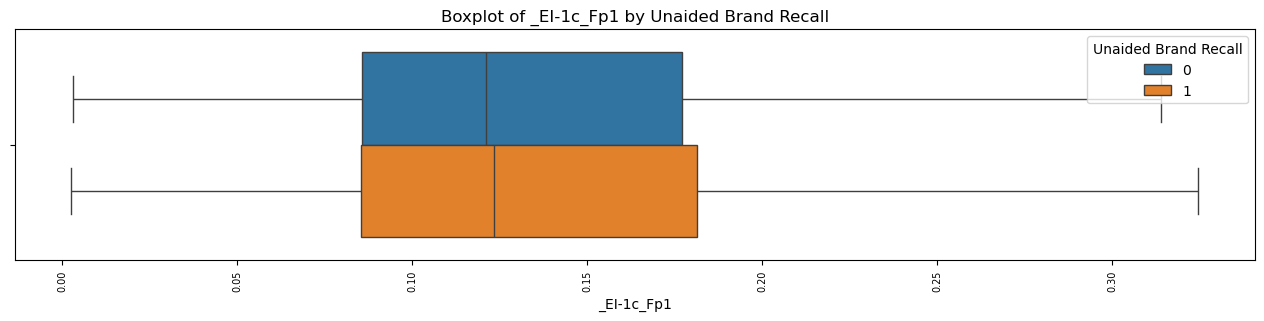

<< RemovedDueToNDA >>

In [103]:
plt.figure(figsize=(16,3))
sns.boxplot(
    data=df,
    hue='unaided_brand_recall',

    x='EI-1c_Fp1',
    # hue='unaided_brand_recall',
    showfliers=False,
    # palette={0: 'lightgray', 1: 'green'},

)
plt.xlabel('_EI-1c_Fp1')
plt.title('Boxplot of _EI-1c_Fp1 by Unaided Brand Recall')
plt.xticks(rotation=90, fontsize=7)
plt.grid(False)
plt.legend(title='Unaided Brand Recall', loc='upper right')
plt.show()

plt.figure(figsize=(16,3))
sns.boxplot(
    data=df,
    x='brand',
    y='EI-1c_Fp1',
    hue='unaided_brand_recall',
    showfliers=False,
    palette={0: 'lightgray', 1: 'green'}
)
plt.xlabel('Brand')
plt.title('Boxplot of z-a-log_EI-1c_All by Brand')
plt.xticks(rotation=90, fontsize=7)
plt.grid(False)
plt.show()